共检测到 8 个圆，已全部绘制


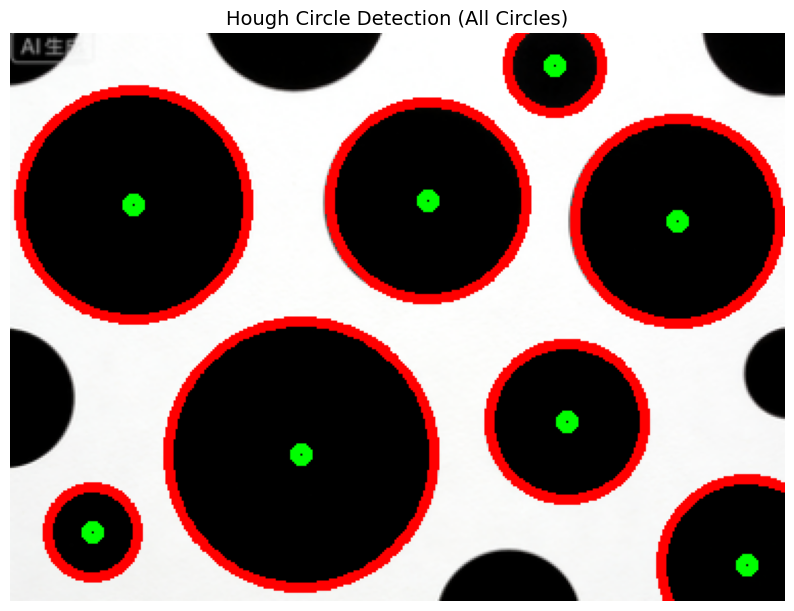

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 配置图片显示
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 读取本地图片
img = cv2.imread('circle.png')
if img is None:
    raise FileNotFoundError("未找到circle.png！请确认图片在代码同级目录")

# 图像预处理
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 霍夫圆检测
circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=30,
    param1=50,
    param2=25,
    minRadius=5,
    maxRadius=0
)

# 绘制检测到的圆
img_circles = img.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for circle in circles[0, :]:
        x, y, r = circle[0], circle[1], circle[2]
        cv2.circle(img_circles, (x, y), 3, (0, 255, 0), 4)
        cv2.circle(img_circles, (x, y), r, (0, 0, 255), 3)
    print(f"共检测到 {len(circles[0, :])} 个圆，已全部绘制")
else:
    print("未检测到任何圆！可尝试降低param2至20或减小minDist至20")

# 显示结果
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_circles, cv2.COLOR_BGR2RGB))
plt.title('Hough Circle Detection')
plt.axis('off')
plt.show()